# Импортируем библиотеки


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor

# Читаем файлы


In [46]:
df1 = pd.read_csv('skab_valve_1.csv', sep = ';')
df1.head()

,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
0,2020-03-09 12:34:37,0.028030,0.040400,1.18285,0.054711,69.9219,24.9122,229.918,32.9875,0.0,0.0
1,2020-03-09 12:34:38,0.026952,0.038880,1.45268,-0.273216,69.9147,24.9038,219.566,32.0129,0.0,0.0
2,2020-03-09 12:34:39,0.027958,0.040660,1.02300,0.054711,69.8861,24.9055,237.717,32.9875,0.0,0.0
3,2020-03-09 12:34:40,0.027277,0.040736,1.22751,-0.273216,69.8397,24.9110,227.621,32.0000,0.0,0.0
4,2020-03-09 12:34:41,0.027210,0.039489,1.21526,-0.273216,69.9136,24.9110,221.634,32.0129,0.0,0.0


In [47]:
df2 = pd.read_csv('machine_temperature_system_failure.csv')
df2.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [48]:
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
df2.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


# Визуализируйте ряд и на основе его внешнего вида сделайте предположения о его компонентах (тренд, сезонность) и стационарности

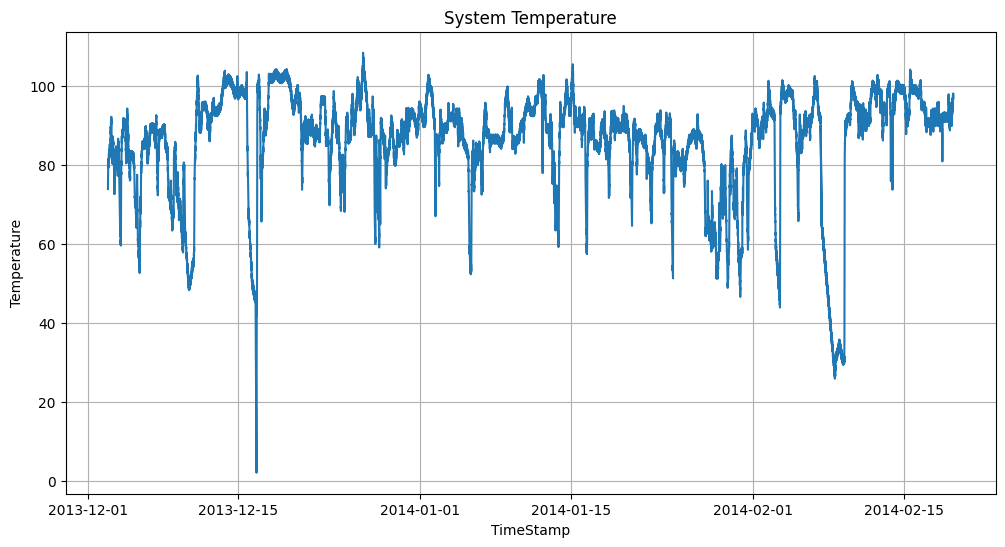

Среднее: 85.926
Стандартное отклонение: 13.747
Минимальное значение: 2.085
Максимальное значение: 108.511


In [49]:
plt.figure(figsize = (12, 6))
plt.plot(df2['timestamp'], df2['value'])
plt.title('System Temperature')
plt.xlabel('TimeStamp')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

print(f"Среднее: {df2['value'].mean():.3f}")
print(f"Стандартное отклонение: {df2['value'].std():.3f}")
print(f"Минимальное значение: {df2['value'].min():.3f}")
print(f"Максимальное значение: {df2['value'].max():.3f}")

Почти все колебания с 2013 по 2014 год находятся в диапозоне от 70 до 100 градусов (если брать средние значения). Какого-то явного тренда на изменение температуры нет - данных колеблются.
2013-12-15 и 2014-02-01 наблюдаются резкие спады температуры, что может говорить о неисправности или отключении системы.
В заключение, регулярного колебания не наблюдается, соответственно, нельзя говорить о какой-либо сезонности. Таким образом, времянной ряд можно назвать псевдостационарым (все колебания происходят около почти стабильного среднего значения).

# Сделайте train/test split

In [50]:
X = df2['timestamp']
y = df2['value'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle = False
)

random state по сути не нужен, потому что у временного ряда последовательное разбиение

# Выбор метрики


Для оценки предсказаний временных рядов лучше всего подойдут регрессионные метрики, так как основная задача это предсказать изменение во времени непрерывных величин (что и есть основная задача регрессии). Учитывая это наиболее подойдет метрики измерения ошибок: MSE (mean squred error), MAE (mean absolute error), MAPE (mean absolute percentage error), RMSE (rott mean squared error). Обращая внимание на модели, с которыми в дальнейшем мы будем взаимодействовать, лучше всего сфокусироваться на RMSE, так как это по сути стандарт для измерения отклонений временных рядов, и метрика достаточно устойчива к крупным отклонениям.

Постройте бейзлайн в виде наивного прогноза или скользящего среднего


In [51]:
naive_pred = np.roll(y_test, 1)
naive_pred[0] = y_train[-1]
naive_pred

array([58.61288987, 58.3668834 , 58.48830129, ..., 97.80416849,
       97.13546835, 98.05685212])

Визуализируйте результаты работы модели, произведите замеры качества с выбранной метрикой

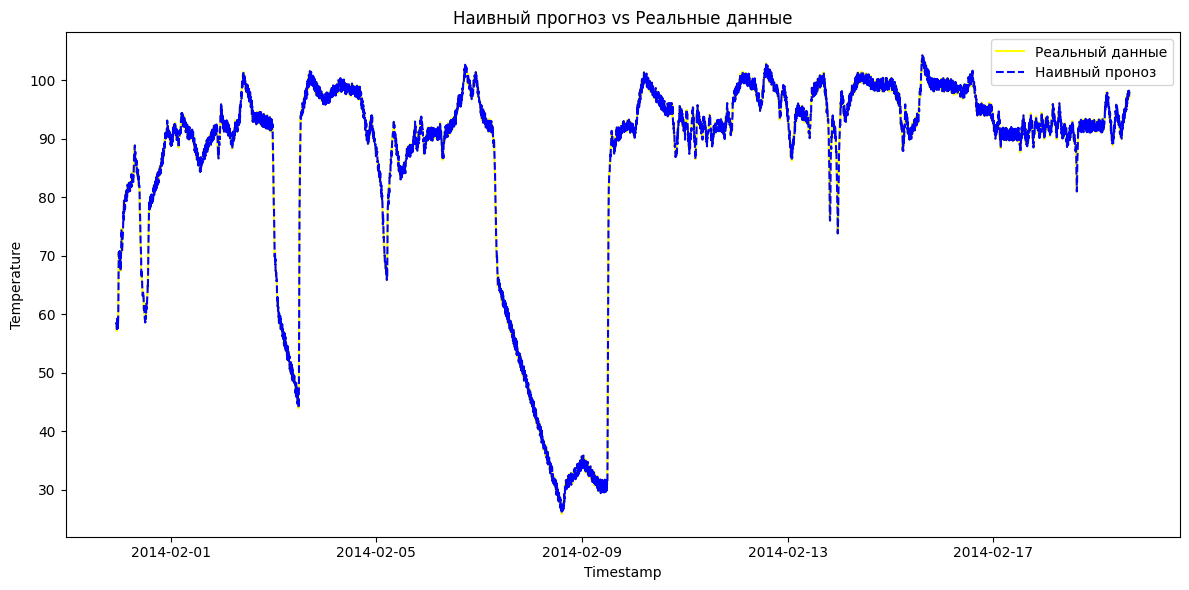

In [52]:
plt.figure(figsize = (12, 6))
plt.plot(X_test, y_test, label='Реальный данные', color='yellow')
plt.plot(X_test, naive_pred, label='Наивный проноз', color='blue', linestyle='--')
plt.title('Наивный прогноз vs Реальные данные')
plt.xlabel('Timestamp')
plt.ylabel('Temperature')
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
rmse = np.sqrt(mean_squared_error(y_test, naive_pred))
print(f'RMSE: {rmse:.3f}')

RMSE: 1.081


Данные наивного прогноза практически точно повторяют реальные данные, так как наивный прогноз берет предыдущее значение, а реальные данные достаточно частотны, чтобы передать тот же паттерн.

Тест Дики-Фуллера

In [54]:
adf = adfuller(df2['value'])
print('ADF:', adf[0])
print('pvalue:', adf[1])
print('observations:', adf[3])
print('critical values:', adf[4])

ADF: -7.369089564491334
pvalue: 9.07134531551863e-11
observations: 22674
critical values: {'1%': np.float64(-3.4306384378792365), '5%': np.float64(-2.861667480233377), '10%': np.float64(-2.566837854101014)}


Временной ряд является стационарным, это видно уже по основной метрике ADF, она меньше, чем все критические значения. А значит и дифференцировать его не нужно. Эту гипотезу так же подтвержлает почти нулевое pvalue (9.071e-11 < 0.05). Следовательно, подкрепляя изначальную визаулизацию, можно смело говорить, что временной ряд не имеет тренда.

# Графики ACF/PACF

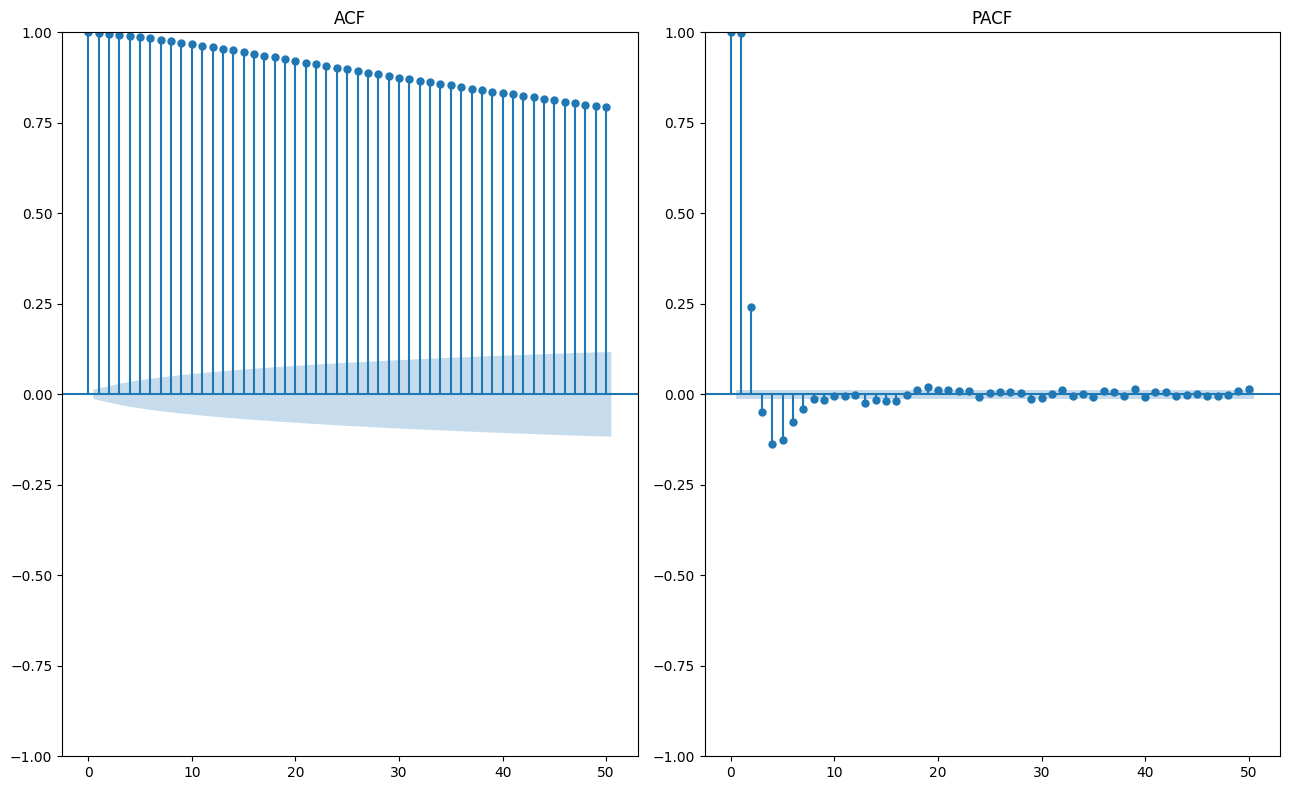

In [55]:
plt.figure(figsize=(13, 8))
plt.subplot(1, 2, 1)
plot_acf(df2['value'], lags=50, ax=plt.gca(), title='ACF')

plt.subplot(1, 2, 2)
plot_pacf(df2['value'], lags=50, ax=plt.gca(), title='PACF')
plt.tight_layout()
plt.show()

Временной ряд не обладает сезонностью, это особенно видно по PACF, так как все значения кроме первого близки к нулю, то есть следующее зависимо от предыдущего. К тому же соседние (как раз предыдущее и следущее) имеют сильную зависимость, так как ACF постеменно убывает. Следовательно, временной ряд стационарный и несезонный.

По результатам всех проведеных тестов, уже можно сказать, что ряд очень стационарен, и дополнительные преобразования будут излишни. Единственное, удалены дубликаты и задана частота - 5 мин.

In [56]:
df2['timestamp'] = pd.to_datetime(df2['timestamp'])
df2 = df2.set_index('timestamp')

In [57]:
df2 = df2[~df2.index.duplicated(keep='first')]
df2 = df2.asfreq('5min')
df2['value'] = df2['value'].interpolate()

In [58]:
y = df2['value']
model = sm.tsa.ARIMA(y, order=(2, 0, 2))
result = model.fit()

In [59]:
y_pred_arima = result.get_forecast(steps=1000)
y_pred_mean = y_pred_arima.predicted_mean
y_pred_conf = y_pred_arima.conf_int()

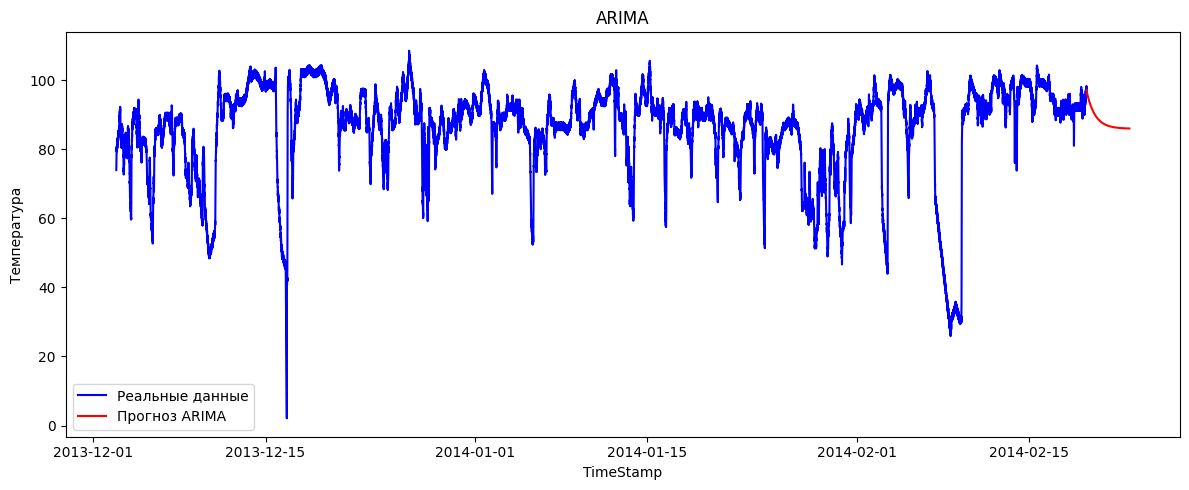

In [60]:
plt.figure(figsize=(12, 5))
plt.plot(df2['value'], label='Реальные данные', color='blue')
plt.plot(y_pred_mean.index, y_pred_mean, label='Прогноз ARIMA', color='red')
plt.title('ARIMA')
plt.xlabel('TimeStamp')
plt.ylabel('Температура')
plt.legend()
plt.tight_layout()
plt.show()

Замеры качества модели ARIMA

In [61]:
y_test1000 = df2['value'][-len(y_pred_mean):]
rmse_arima = np.sqrt(mean_squared_error(y_test1000, y_pred_mean))
print(f'ARIMA RMSE: {rmse_arima:.3f}')

ARIMA RMSE: 5.605


Из-за практически отсутствия сезонности и высокой стационарности, модель сглаживается в конце, тем не менее RMSE показывает, что модель точна, и тренд далее пойдет вниз.

#Классическая модель

In [62]:
df2['lag1'] = df2['value'].shift(1)
df2['lag2'] = df2['value'].shift(2)
df2['lag3'] = df2['value'].shift(3)
df2['rolling_mean3'] = df2['value'].rolling(window=3).mean()
df2['rolling_std3'] = df2['value'].rolling(window=3).std()
df2['rolling_mean10'] = df2['value'].rolling(window=10).mean()
df2['rolling_std10'] = df2['value'].rolling(window=10).std()
df2['hour'] = df2.index.hour
df2['day'] = df2.index.day
df2['weekday'] = df2.index.weekday
df2['month'] = df2.index.month
df2 = df2.dropna()
df2.head()

,value,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean10,rolling_std10,hour,day,weekday,month
timestamp,,,,,,,,,,,,
2013-12-02 22:00:00,79.486523,80.353425,80.272828,80.269784,80.037592,0.478938,78.159089,2.339895,22,2,0,12
2013-12-02 22:05:00,80.783277,79.486523,80.353425,80.272828,80.207742,0.660538,78.840684,1.942098,22,2,0,12
2013-12-02 22:10:00,79.508159,80.783277,79.486523,80.353425,79.925986,0.742514,79.297912,1.376516,22,2,0,12
2013-12-02 22:15:00,79.302033,79.508159,80.783277,79.486523,79.864489,0.802340,79.615699,0.814495,22,2,0,12
2013-12-02 22:20:00,80.802624,79.302033,79.508159,80.783277,79.870938,0.813419,79.881891,0.706731,22,2,0,12


In [63]:
X_new = df2.drop(columns=['value'])
y_new = df2['value']
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.25, shuffle=False)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_new, y_train_new)
y_pred_rf = rf_model.predict(X_test_new)

Визуализируйте результаты работы модели, произведите замеры качества модели

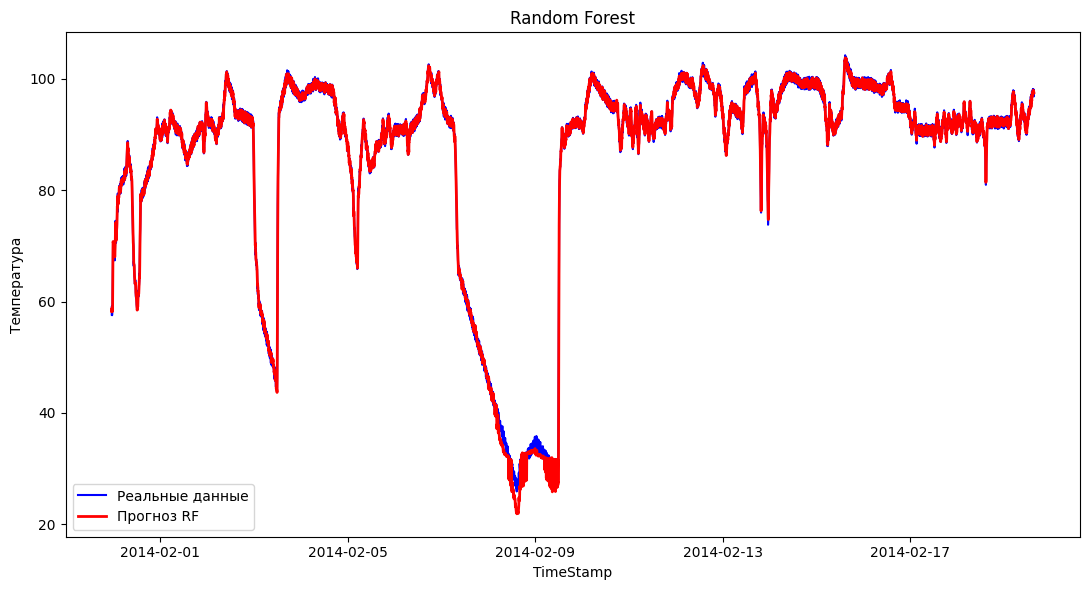

In [64]:
plt.figure(figsize=(11, 6))
plt.plot(y_test_new.index, y_test_new.values, label='Реальные данные', color='blue')
plt.plot(y_test_new.index, y_pred_rf, label='Прогноз RF', color='red', linewidth=2)
plt.title('Random Forest')
plt.xlabel('TimeStamp')
plt.ylabel('Температура')
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
rmse_rf = np.sqrt(mean_squared_error(y_test_new, y_pred_rf))
print(f"RF RMSE: {rmse_rf:.3f}")

RF RMSE: 0.822


Random Forest показала более точный результат, чем ARIMA (видно по графику и RMSE). Предсказания случайного леса почти в точности повторяют реальные данные, даже резкин перепады. Можно сделать вывод, что асмблевый метод (случайный лес) работает лучше с временными рядами, чем линейные модели (ARIMA).